# Final Test Evaluation

This notebook opens the untouched test split once.

The model and configuration were frozen during Step 011. No test result
is used for tuning.

## One-time evaluation rule

A completion marker is written only after the final reports are saved.

If the marker already exists, the notebook stops before loading or
evaluating the test examples.

In [1]:
from pathlib import Path
import sys

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset_builder import (
    build_development_dataset,
)
from src.final_test_evaluation import (
    assert_test_not_previously_evaluated,
    build_final_evaluation_summary,
    build_final_predictions_table,
    verify_final_evaluation_preconditions,
    write_test_evaluation_marker,
)
from src.multimodal_neural_network import (
    LABEL_ORDER,
    create_multimodal_dataset,
    decode_predictions,
    encode_labels,
)

keras.utils.set_random_seed(42)

In [2]:
processed_directory = (
    project_root
    / "data"
    / "processed"
)

reports_directory = (
    project_root
    / "reports"
)

models_directory = (
    project_root
    / "models"
)

marker_path = (
    reports_directory
    / "final_test_evaluation_completed.json"
)

assert_test_not_previously_evaluated(
    marker_path
)

print(
    "Final test evaluation marker:",
    marker_path,
)

print(
    "Marker exists:",
    marker_path.exists(),
)

Final test evaluation marker: C:\Users\stana\Desktop\chart-claim-verification-bg\reports\final_test_evaluation_completed.json
Marker exists: False


## Load split metadata and frozen validation decision

In [3]:
train_data = pd.read_csv(
    processed_directory
    / "train_chart_claim_dataset.csv"
)

validation_data = pd.read_csv(
    processed_directory
    / "validation_chart_claim_dataset.csv"
)

test_data = pd.read_csv(
    processed_directory
    / "test_chart_claim_dataset.csv"
)

selected_metrics = pd.read_csv(
    reports_directory
    / "multimodal_best_validation_metrics.csv"
)

verify_final_evaluation_preconditions(
    train_data=train_data,
    validation_data=validation_data,
    test_data=test_data,
    selected_metrics=selected_metrics,
)

print("Training rows:", len(train_data))
print(
    "Validation rows:",
    len(validation_data),
)
print("Test rows:", len(test_data))
print(
    "Test chart groups:",
    test_data[
        "chart_group_id"
    ].nunique(),
)

selected_metrics

Training rows: 252
Validation rows: 54
Test rows: 54
Test chart groups: 2


,model,config_name,accuracy,macro_f1,evaluation_split
0,Tuned Keras multimodal neural network,baseline,0.888889,0.8885,validation


## Verify the frozen local model

In [4]:
final_model_path = (
    models_directory
    / (
        "tuned_multimodal_"
        "neural_network.keras"
    )
)

if not final_model_path.exists():
    raise FileNotFoundError(
        "The tuned multimodal model is missing. "
        "Run Step 011 successfully before Step 012. "
        f"Expected path: {final_model_path}"
    )

print(
    "Frozen model:",
    final_model_path,
)

Frozen model: C:\Users\stana\Desktop\chart-claim-verification-bg\models\tuned_multimodal_neural_network.keras


## Recreate ignored chart images when needed

In [5]:
first_test_image_path = (
    project_root
    / test_data["image_path"].iloc[0]
)

if not first_test_image_path.exists():
    source_data = pd.read_csv(
        processed_directory
        / "eu_unemployment_2019_2025.csv"
    )

    build_development_dataset(
        data=source_data,
        output_directory=(
            project_root
            / "data"
            / "generated"
            / "charts"
            / "development"
        ),
    )

print(
    "First test image exists:",
    first_test_image_path.exists(),
)

First test image exists: True


## Build the untouched test dataset

In [6]:
test_text = (
    test_data["claim_text"]
    .astype(str)
    .to_numpy()
)

test_labels = encode_labels(
    test_data["label"]
)

test_image_paths = [
    str(project_root / relative_path)
    for relative_path
    in test_data["image_path"]
]

test_dataset = (
    create_multimodal_dataset(
        image_paths=test_image_paths,
        claim_texts=test_text,
        labels=test_labels,
        image_size=96,
        batch_size=16,
        shuffle=False,
    )
)

print(
    "Prepared test examples:",
    len(test_data),
)

Prepared test examples: 54


## Load the frozen model and evaluate once

In [7]:
final_model = keras.models.load_model(
    final_model_path
)

test_probabilities = final_model.predict(
    test_dataset,
    verbose=0,
)

test_prediction_indices = np.argmax(
    test_probabilities,
    axis=1,
)

test_predictions = decode_predictions(
    test_prediction_indices
)

test_accuracy = accuracy_score(
    test_data["label"],
    test_predictions,
)

test_macro_f1 = f1_score(
    test_data["label"],
    test_predictions,
    average="macro",
    zero_division=0,
)

final_test_metrics = pd.DataFrame(
    [
        {
            "model": (
                "Final Keras multimodal "
                "neural network"
            ),
            "config_name": "baseline",
            "accuracy": test_accuracy,
            "macro_f1": test_macro_f1,
            "evaluation_split": "test",
            "test_size": len(test_data),
        }
    ]
)

final_test_metrics

,model,config_name,accuracy,macro_f1,evaluation_split,test_size
0,Final Keras multimodal neural network,baseline,0.777778,0.769697,test,54


## Final classification report and confusion matrix

In [8]:
final_test_report = pd.DataFrame(
    classification_report(
        test_data["label"],
        test_predictions,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )
).transpose()

final_test_report

,precision,recall,f1-score,support
supported,1.000000,0.833333,0.909091,18.000000
refuted,0.666667,1.000000,0.800000,18.000000
not_enough_information,0.750000,0.500000,0.600000,18.000000
accuracy,0.777778,0.777778,0.777778,0.777778
macro avg,0.805556,0.777778,0.769697,54.000000
weighted avg,0.805556,0.777778,0.769697,54.000000


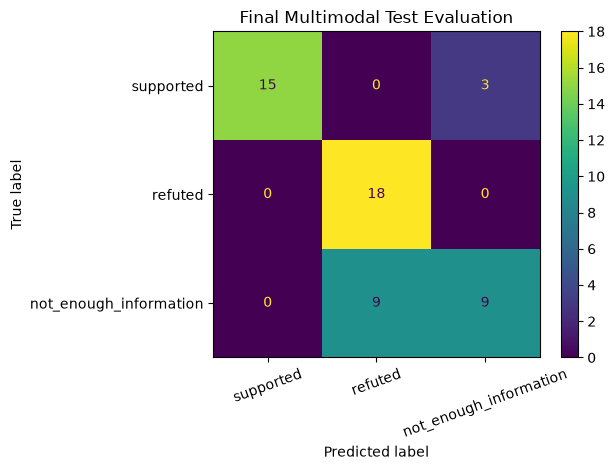

In [9]:
final_test_matrix = confusion_matrix(
    test_data["label"],
    test_predictions,
    labels=LABEL_ORDER,
)

ConfusionMatrixDisplay(
    confusion_matrix=final_test_matrix,
    display_labels=LABEL_ORDER,
).plot(
    xticks_rotation=20,
)

plt.title(
    "Final Multimodal Test Evaluation"
)
plt.tight_layout()
plt.show()

## Row-level predictions and final test errors

In [10]:
final_predictions = (
    build_final_predictions_table(
        test_data=test_data,
        predicted_labels=(
            test_predictions
        ),
        predicted_probabilities=(
            test_probabilities
        ),
        label_order=LABEL_ORDER,
    )
)

final_test_errors = (
    final_predictions.loc[
        ~final_predictions["correct"]
    ]
    .sort_values(
        by="confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Correct test predictions:",
    int(
        final_predictions[
            "correct"
        ].sum()
    ),
)

print(
    "Final test errors:",
    len(final_test_errors),
)

final_test_errors[
    [
        "chart_group_id",
        "claim_text",
        "true_label",
        "predicted_label",
        "confidence",
        "error_type",
    ]
]

Correct test predictions: 42
Final test errors: 12


,chart_group_id,claim_text,true_label,predicted_label,confidence,error_type
0,window_2022_2025,The EU unemployment rate was higher in 2025 th...,supported,not_enough_information,0.904055,supported -> not_enough_information
1,window_2022_2025,The EU unemployment rate was higher in 2025 th...,supported,not_enough_information,0.904054,supported -> not_enough_information
2,window_2022_2025,The EU unemployment rate was higher in 2025 th...,supported,not_enough_information,0.903978,supported -> not_enough_information
3,window_2020_2023,The EU unemployment rate was higher in 2024 th...,not_enough_information,refuted,0.594596,not_enough_information -> refuted
4,window_2020_2023,The EU unemployment rate was higher in 2024 th...,not_enough_information,refuted,0.594524,not_enough_information -> refuted
5,window_2020_2023,The EU unemployment rate was higher in 2024 th...,not_enough_information,refuted,0.593782,not_enough_information -> refuted
6,window_2020_2023,The EU unemployment rate was higher in 2024 th...,not_enough_information,refuted,0.561326,not_enough_information -> refuted
7,window_2020_2023,The EU unemployment rate was higher in 2024 th...,not_enough_information,refuted,0.561283,not_enough_information -> refuted
8,window_2020_2023,The EU unemployment rate was higher in 2024 th...,not_enough_information,refuted,0.560609,not_enough_information -> refuted
9,window_2020_2023,The EU unemployment rate was higher in 2024 th...,not_enough_information,refuted,0.538182,not_enough_information -> refuted


## Validation-to-test generalization gap

In [11]:
validation_accuracy = float(
    selected_metrics.loc[
        0,
        "accuracy",
    ]
)

validation_macro_f1 = float(
    selected_metrics.loc[
        0,
        "macro_f1",
    ]
)

final_evaluation_summary = (
    build_final_evaluation_summary(
        validation_accuracy=(
            validation_accuracy
        ),
        validation_macro_f1=(
            validation_macro_f1
        ),
        test_accuracy=test_accuracy,
        test_macro_f1=test_macro_f1,
    )
)

final_evaluation_summary

,metric,validation_score,test_score,test_minus_validation
0,accuracy,0.888889,0.777778,-0.111111
1,macro_f1,0.888500,0.769697,-0.118803


## Save final reports and completion marker

The marker is written last, after all CSV reports are saved.

In [12]:
reports_directory.mkdir(
    parents=True,
    exist_ok=True,
)

final_test_metrics.to_csv(
    reports_directory
    / "final_test_metrics.csv",
    index=False,
)

final_test_report.to_csv(
    reports_directory
    / "final_test_classification_report.csv"
)

pd.DataFrame(
    final_test_matrix,
    index=[
        f"actual_{label}"
        for label in LABEL_ORDER
    ],
    columns=[
        f"predicted_{label}"
        for label in LABEL_ORDER
    ],
).to_csv(
    reports_directory
    / "final_test_confusion_matrix.csv"
)

final_predictions.to_csv(
    reports_directory
    / "final_test_predictions.csv",
    index=False,
)

final_test_errors.to_csv(
    reports_directory
    / "final_test_errors.csv",
    index=False,
)

final_evaluation_summary.to_csv(
    reports_directory
    / "final_evaluation_summary.csv",
    index=False,
)

write_test_evaluation_marker(
    marker_path=marker_path,
    model_name=(
        "Final Keras multimodal "
        "neural network"
    ),
    config_name="baseline",
    test_size=len(test_data),
    accuracy=test_accuracy,
    macro_f1=test_macro_f1,
)

print(
    "Final test evaluation completed."
)

print(
    "Completion marker written:",
    marker_path,
)

Final test evaluation completed.
Completion marker written: C:\Users\stana\Desktop\chart-claim-verification-bg\reports\final_test_evaluation_completed.json


## Final interpretation

This is the project's final unbiased test estimate under the documented
split and model-selection procedure.

The score must not be used to choose another model or change the
hyperparameters. Any difference from the validation score is reported
as the generalization gap.